# 01 - Paddy Dataset: Initial EDA

This notebook performs the first pass over the UCI Paddy Dataset for the group project. The goal is to load the raw CSV, clean basic metadata, inspect the schema, and produce summary tables that will guide the deeper EDA and modeling steps.

## Setup

The project root is assumed to be one level above this notebook folder.

In [1]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "paddydataset.csv"
OUTPUT_TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

PosixPath('/Users/cherice/Documents/2601 ISYE 6740/GroupProject/data/paddydataset.csv')

## Load Data

Column names are stripped of leading/trailing spaces so downstream code can refer to them consistently. The original CSV has a trailing space in `Hectares `.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
df.columns = df.columns.str.strip()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 2,789
Columns: 45


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


## Schema Overview

In [3]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "unique_count": df.nunique(dropna=True).values,
})

schema.to_csv(OUTPUT_TABLE_DIR / "schema_overview.csv", index=False)
schema

,column,dtype,non_null_count,missing_count,missing_pct,unique_count
0,Hectares,int64,2789,0,0.0,6
1,Agriblock,str,2789,0,0.0,6
2,Variety,str,2789,0,0.0,3
3,Soil Types,str,2789,0,0.0,2
4,Seedrate(in Kg),int64,2789,0,0.0,6
5,LP_Mainfield(in Tonnes),float64,2789,0,0.0,6
6,Nursery,str,2789,0,0.0,2
7,Nursery area (Cents),int64,2789,0,0.0,6
8,LP_nurseryarea(in Tonnes),int64,2789,0,0.0,6
9,DAP_20days,int64,2789,0,0.0,6


## Missing Values and Duplicate Rows

In [4]:
missing_total = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

print(f"Total missing values: {missing_total:,}")
print(f"Duplicate rows: {duplicate_rows:,}")

missing_by_column = df.isna().sum().sort_values(ascending=False)
missing_by_column[missing_by_column > 0]

Total missing values: 0
Duplicate rows: 451


Series([], dtype: int64)

## Numeric and Categorical Columns

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)
print()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Numeric columns (37):
['Hectares', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)', 'Paddy yield(in Kg)']

Categorical columns (8):
['Agriblock', 'Variety', 'Soil Types', 'Nursery', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60',

## Numeric Summary

In [6]:
numeric_summary = df[numeric_cols].describe().T
numeric_summary["missing_count"] = df[numeric_cols].isna().sum()
numeric_summary["unique_count"] = df[numeric_cols].nunique()

numeric_summary.to_csv(OUTPUT_TABLE_DIR / "numeric_summary.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,unique_count
Hectares,2789.0,3.717461,1.437777,1.00,3.00,4.00,5.00,6.00,0,6
Seedrate(in Kg),2789.0,92.936536,35.944420,25.00,75.00,100.00,125.00,150.00,0,6
LP_Mainfield(in Tonnes),2789.0,46.468268,17.972210,12.50,37.50,50.00,62.50,75.00,0,6
Nursery area (Cents),2789.0,74.349229,28.755536,20.00,60.00,80.00,100.00,120.00,0,6
LP_nurseryarea(in Tonnes),2789.0,3.717461,1.437777,1.00,3.00,4.00,5.00,6.00,0,6
DAP_20days,2789.0,148.698458,57.511072,40.00,120.00,160.00,200.00,240.00,0,6
Weed28D_thiobencarb,2789.0,7.434923,2.875554,2.00,6.00,8.00,10.00,12.00,0,6
Urea_40Days,2789.0,100.854729,39.006885,27.13,81.39,108.52,135.65,162.78,0,6
Potassh_50Days,2789.0,38.587250,14.924123,10.38,31.14,41.52,51.90,62.28,0,6
Micronutrients_70Days,2789.0,55.761922,21.566652,15.00,45.00,60.00,75.00,90.00,0,6


## Categorical Summary

In [7]:
cat_rows = []
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    top_value = counts.index[0] if len(counts) else None
    top_count = int(counts.iloc[0]) if len(counts) else 0
    cat_rows.append({
        "column": col,
        "unique_count": df[col].nunique(dropna=True),
        "top_value": top_value,
        "top_count": top_count,
        "top_pct": round(top_count / len(df) * 100, 2),
    })

categorical_summary = pd.DataFrame(cat_rows)
categorical_summary.to_csv(OUTPUT_TABLE_DIR / "categorical_summary.csv", index=False)
categorical_summary

,column,unique_count,top_value,top_count,top_pct
0,Agriblock,6,Sankarapuram,605,21.69
1,Variety,3,ponmani,1061,38.04
2,Soil Types,2,clay,1521,54.54
3,Nursery,2,dry,1540,55.22
4,Wind Direction_D1_D30,6,SSE,605,21.69
5,Wind Direction_D31_D60,5,W,1055,37.83
6,Wind Direction_D61_D90,5,SE,899,32.23
7,Wind Direction_D91_D120,6,NW,605,21.69


## Target / Outcome Candidate

The dataset includes `Paddy yield(in Kg)`, which can be treated as an outcome variable for interpretation, supervised baselines, or cluster profiling. The main project remains unsupervised, so this column should be handled deliberately depending on the analysis stage.

In [8]:
yield_col = "Paddy yield(in Kg)"

if yield_col in df.columns:
    yield_summary = df[yield_col].describe().to_frame(name=yield_col)
    yield_summary.to_csv(OUTPUT_TABLE_DIR / "yield_summary.csv")
    display(yield_summary)
else:
    print(f"{yield_col!r} was not found in the dataset.")

,Paddy yield(in Kg)
count,2789.000000
mean,22517.728935
std,9199.661393
min,5410.000000
25%,16389.000000
50%,24636.000000
75%,31035.000000
max,38814.000000


## Save Cleaned Preview

This keeps a small cleaned sample for quick inspection and portal prototyping. The full raw dataset remains unchanged in `data/paddydataset.csv`.

In [9]:
df.head(25).to_csv(OUTPUT_TABLE_DIR / "cleaned_preview_25_rows.csv", index=False)
print(f"Saved summary tables to: {OUTPUT_TABLE_DIR}")

Saved summary tables to: /Users/cherice/Documents/2601 ISYE 6740/GroupProject/outputs/tables


# Step 3 - Exploratory Data Analysis

This section adds deeper exploratory analysis: distributions, category frequencies, relationships with yield, correlations, duplicate patterns, and basic outlier flags. Figures are saved to `outputs/figures` and tables are saved to `outputs/tables`.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

## Distribution of Key Numeric Variables

These variables cover farm size, seed/fertilizer inputs, weather, and yield. They help identify skewed variables and unusual ranges before preprocessing.

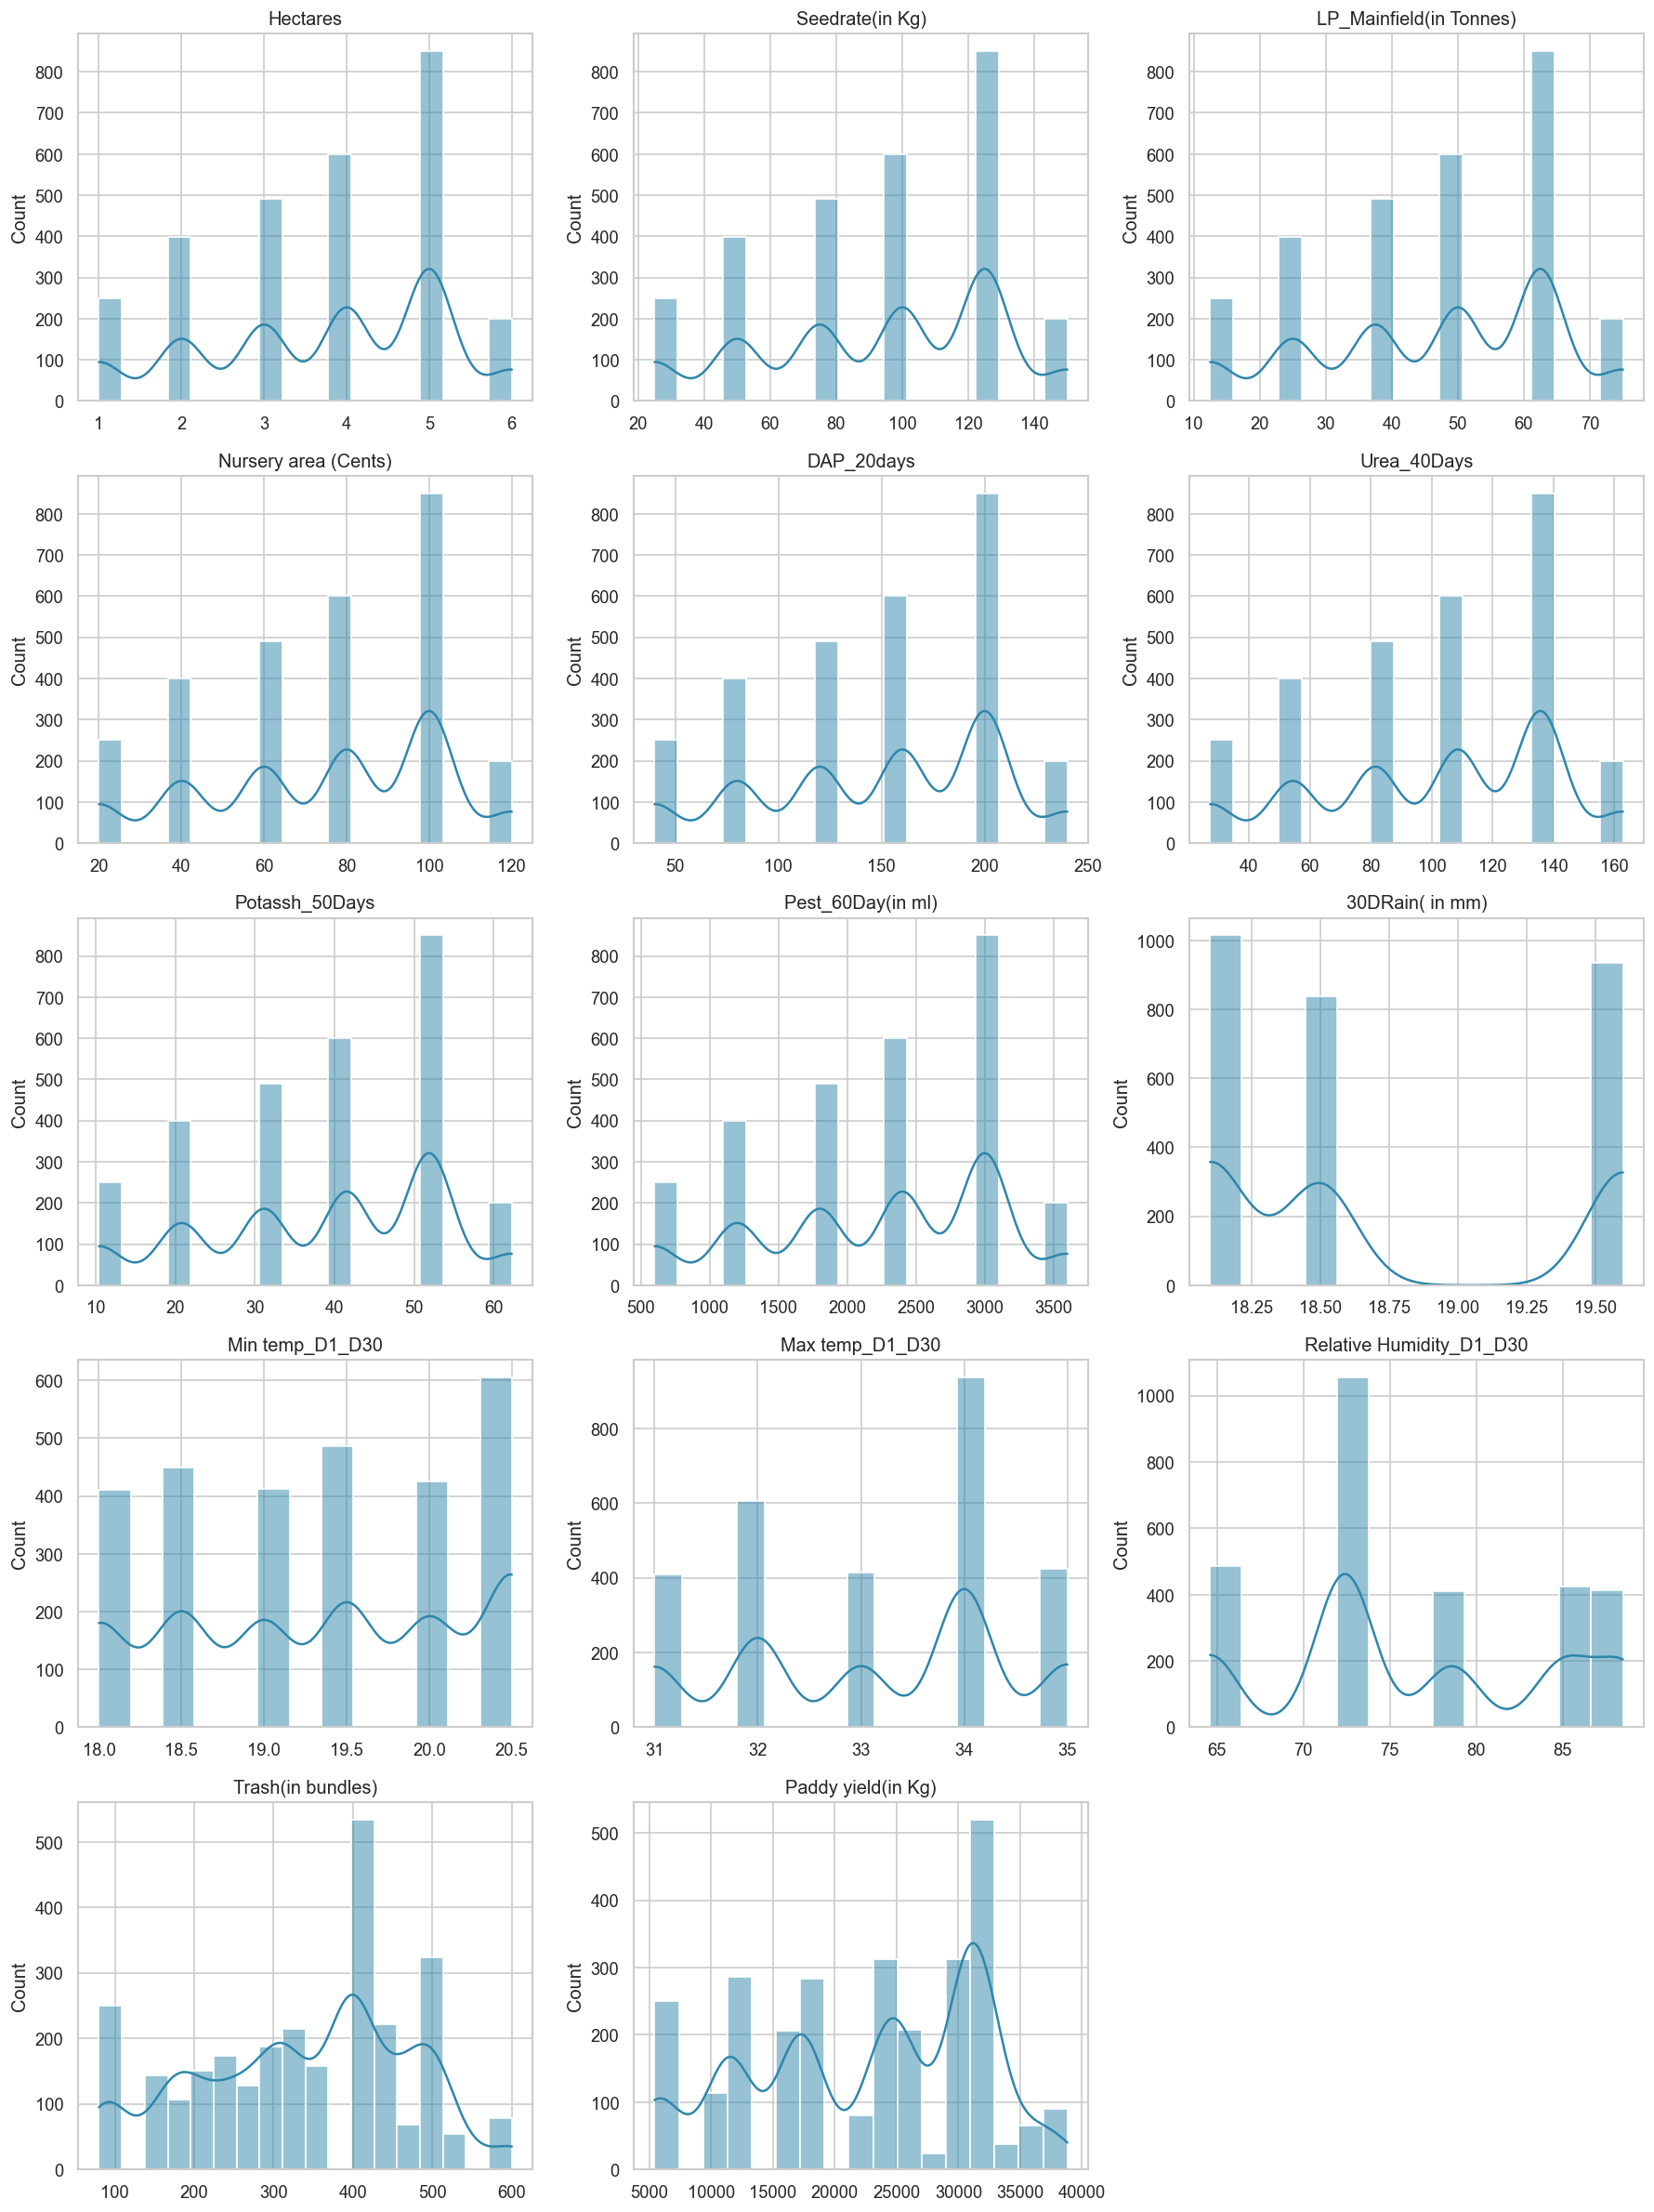

In [11]:
key_numeric_cols = [
    "Hectares",
    "Seedrate(in Kg)",
    "LP_Mainfield(in Tonnes)",
    "Nursery area (Cents)",
    "DAP_20days",
    "Urea_40Days",
    "Potassh_50Days",
    "Pest_60Day(in ml)",
    "30DRain( in mm)",
    "Min temp_D1_D30",
    "Max temp_D1_D30",
    "Relative Humidity_D1_D30",
    "Trash(in bundles)",
    "Paddy yield(in Kg)",
]
key_numeric_cols = [col for col in key_numeric_cols if col in df.columns]

ncols = 3
nrows = int(np.ceil(len(key_numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, key_numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86AB")
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(key_numeric_cols):]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "key_numeric_distributions.png", bbox_inches="tight")
plt.show()

## Categorical Feature Frequencies

These plots show whether categories are balanced or dominated by a small number of values.

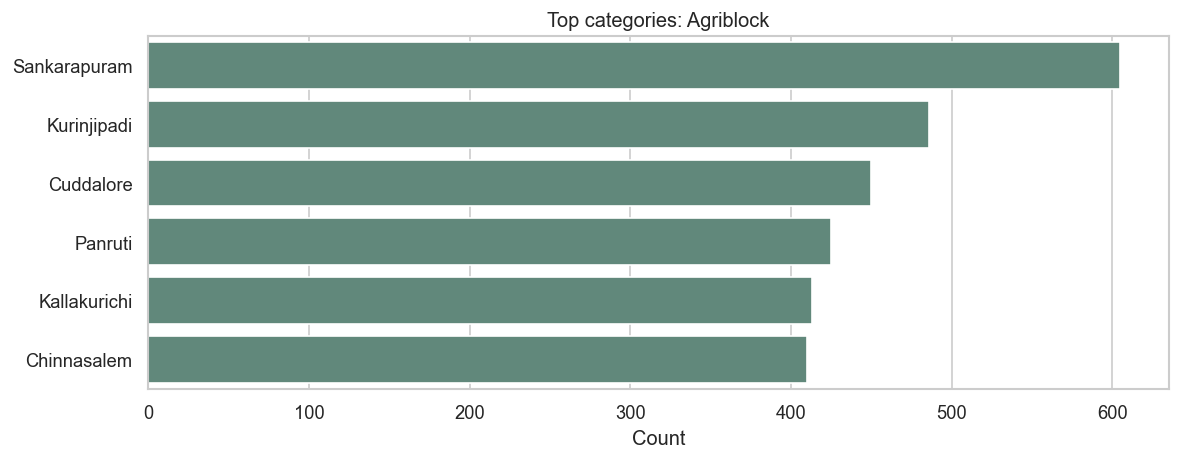

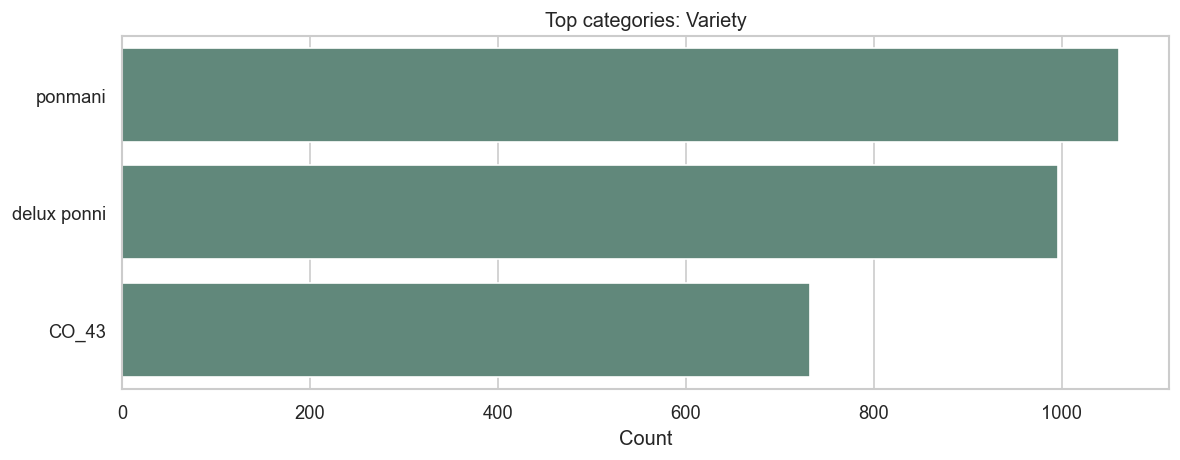

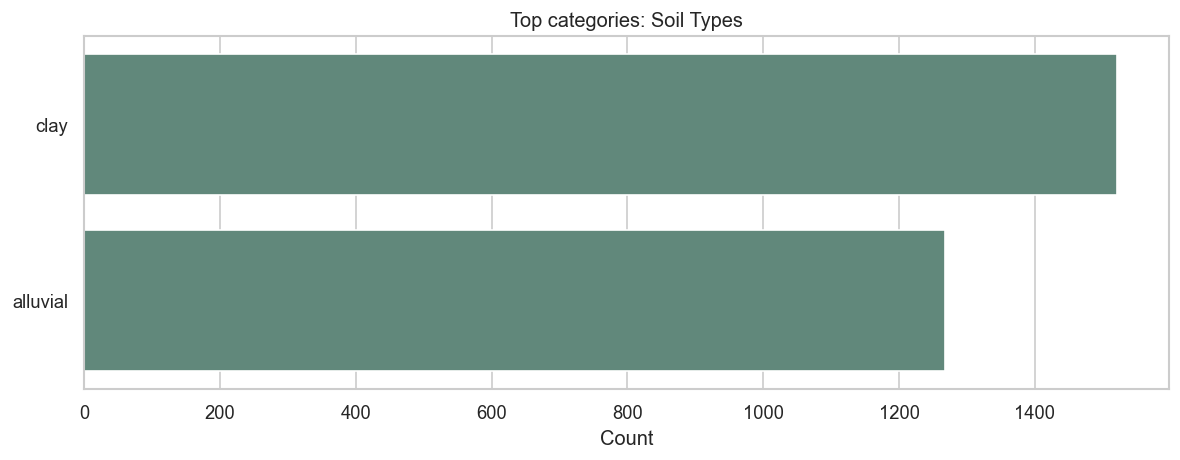

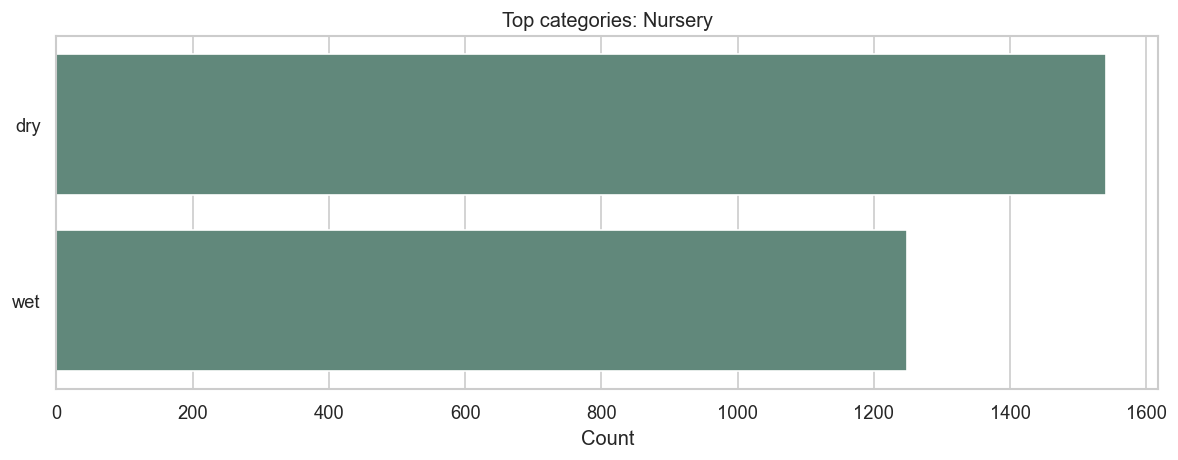

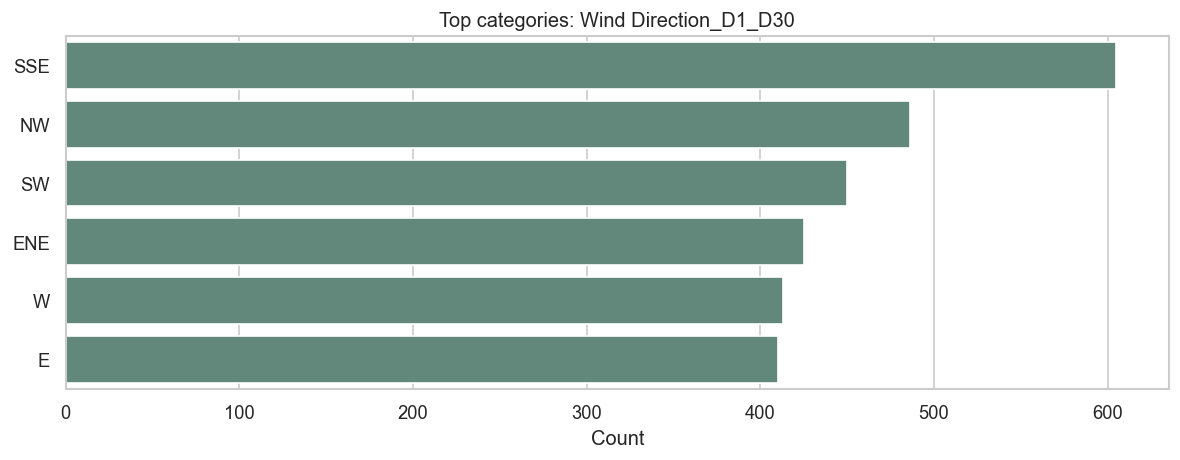

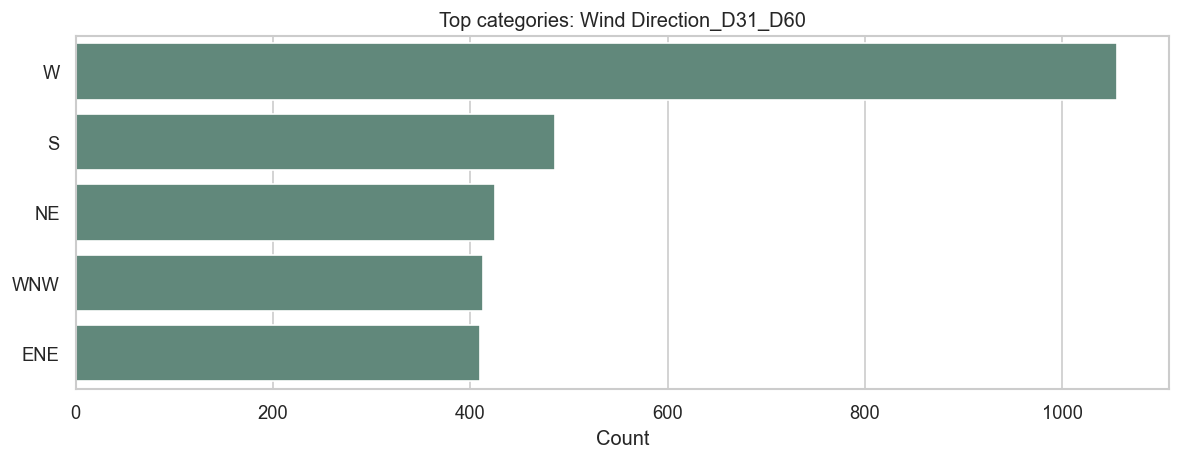

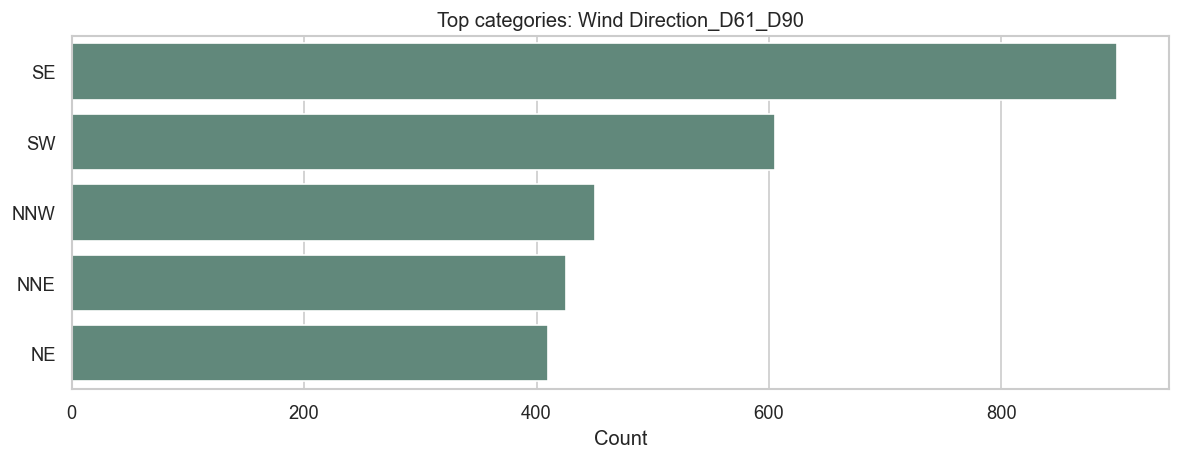

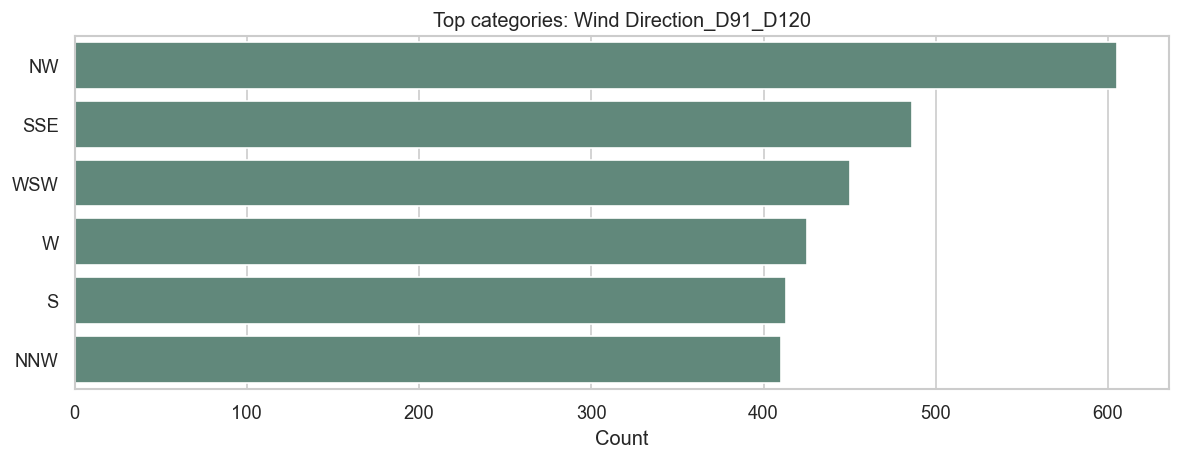

In [12]:
for col in categorical_cols:
    counts = df[col].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(counts))))
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax, color="#5B8E7D")
    ax.set_title(f"Top categories: {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    fig.tight_layout()
    safe_name = col.replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(FIGURE_DIR / f"category_counts_{safe_name}.png", bbox_inches="tight")
    plt.show()

## Yield by Major Categories

Although the core project is unsupervised, yield is useful for interpreting whether discovered groups correspond to meaningful agricultural outcomes.

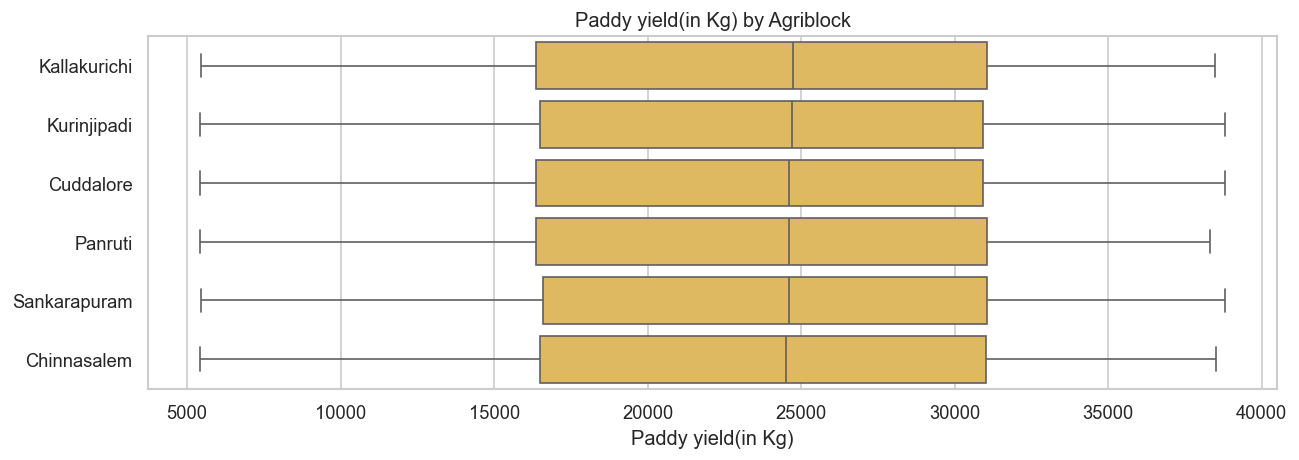

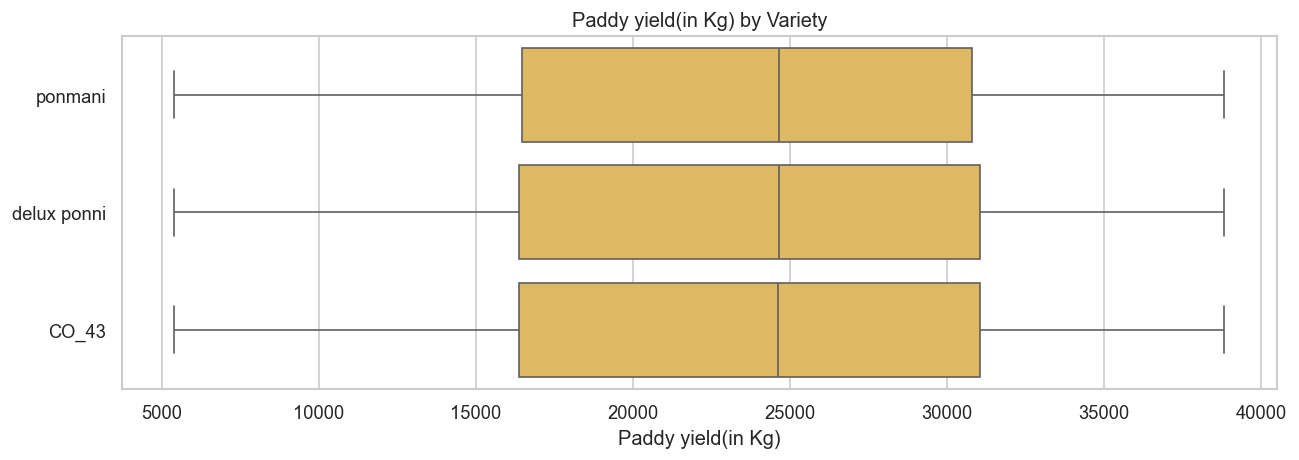

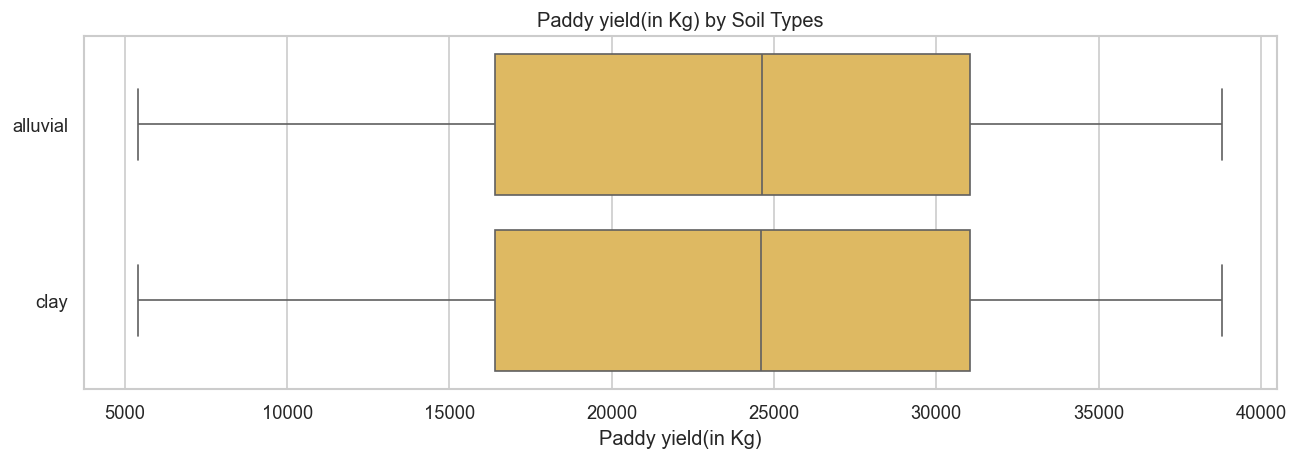

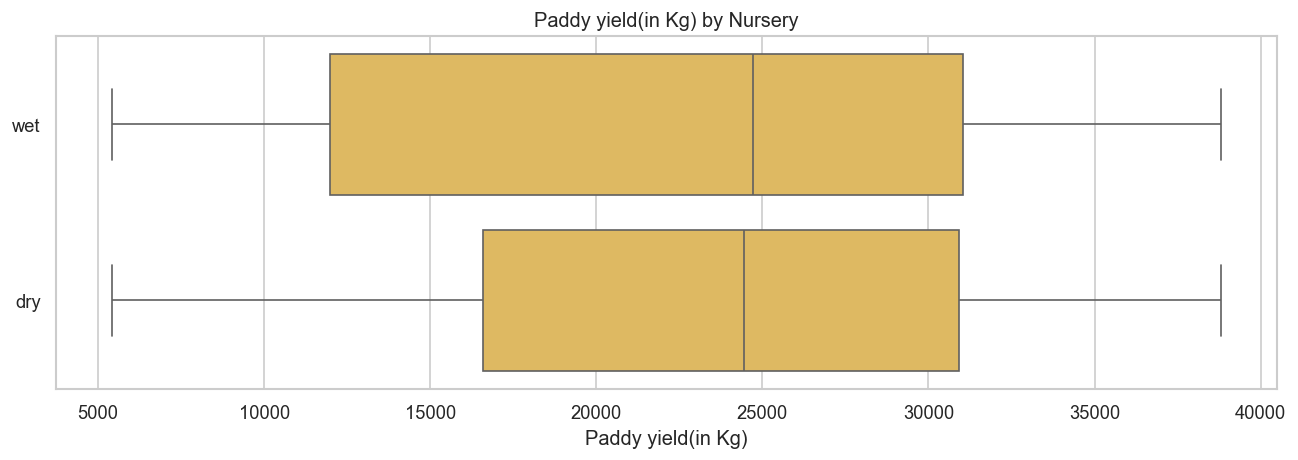

In [13]:
yield_col = "Paddy yield(in Kg)"
category_yield_cols = [col for col in ["Agriblock", "Variety", "Soil Types", "Nursery"] if col in df.columns]

for col in category_yield_cols:
    order = df.groupby(col)[yield_col].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(11, max(4, 0.35 * len(order))))
    sns.boxplot(data=df, x=yield_col, y=col, order=order, ax=ax, color="#F2C14E")
    ax.set_title(f"{yield_col} by {col}")
    ax.set_xlabel(yield_col)
    ax.set_ylabel("")
    fig.tight_layout()
    safe_name = col.replace("/", "_").replace(" ", "_")
    fig.savefig(FIGURE_DIR / f"yield_by_{safe_name}.png", bbox_inches="tight")
    plt.show()

## Correlation Analysis

The table lists numeric variables most correlated with yield. The heatmap focuses on the strongest relationships to keep the chart readable.

,feature,correlation_with_yield
0,Urea_40Days,0.994649
1,Hectares,0.994649
2,LP_nurseryarea(in Tonnes),0.994649
3,Weed28D_thiobencarb,0.994649
4,Potassh_50Days,0.994649
5,Nursery area (Cents),0.994649
6,DAP_20days,0.994649
7,Micronutrients_70Days,0.994649
8,Seedrate(in Kg),0.994649
9,LP_Mainfield(in Tonnes),0.994649


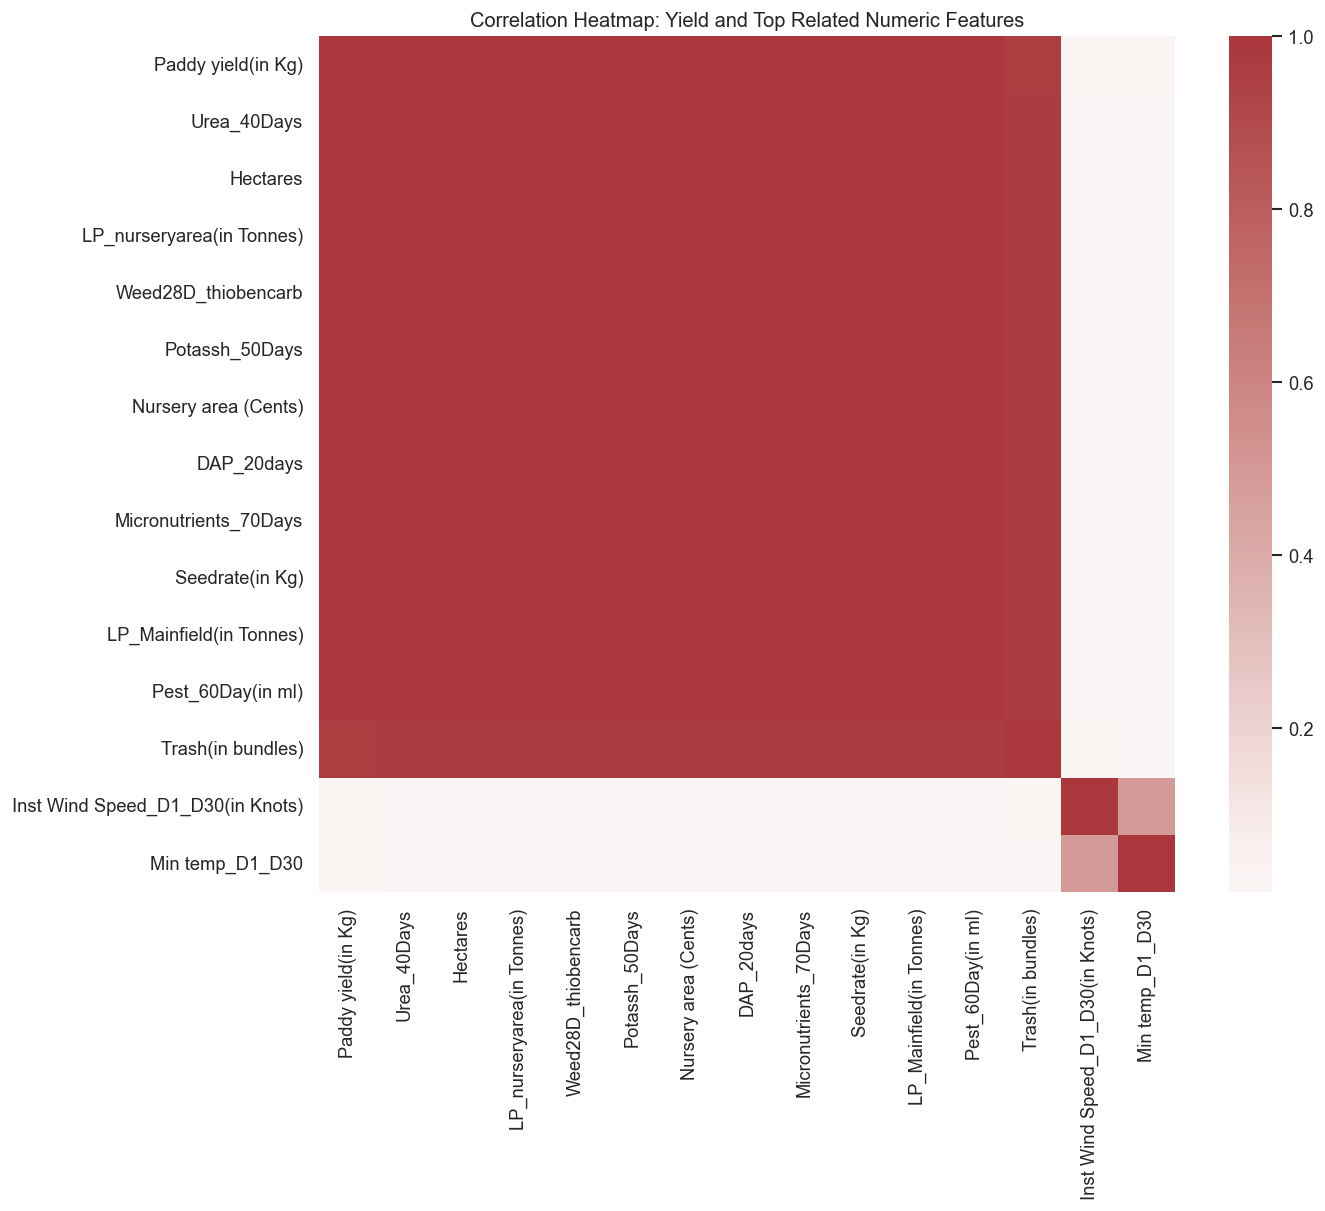

In [14]:
corr = df[numeric_cols].corr(numeric_only=True)
yield_corr = corr[yield_col].drop(yield_col).sort_values(key=lambda s: s.abs(), ascending=False)
yield_corr_table = yield_corr.rename("correlation_with_yield").reset_index().rename(columns={"index": "feature"})
yield_corr_table.to_csv(OUTPUT_TABLE_DIR / "yield_correlations.csv", index=False)
display(yield_corr_table.head(20))

top_corr_cols = [yield_col] + yield_corr.head(14).index.tolist()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[top_corr_cols].corr(), cmap="vlag", center=0, annot=False, square=True, ax=ax)
ax.set_title("Correlation Heatmap: Yield and Top Related Numeric Features")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "yield_top_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Duplicate Pattern Investigation

Step 2 found duplicate rows. This checks whether duplicates are exact full-row repeats and whether they concentrate in particular categories.

In [15]:
duplicate_mask = df.duplicated(keep=False)
duplicates = df.loc[duplicate_mask].copy()

print(f"Rows involved in duplicate groups: {len(duplicates):,}")
print(f"Duplicate rows beyond first occurrence: {df.duplicated().sum():,}")

if len(duplicates):
    duplicate_category_summary = []
    for col in category_yield_cols:
        top = duplicates[col].value_counts(normalize=True).head(10).mul(100).round(2)
        for value, pct in top.items():
            duplicate_category_summary.append({"column": col, "value": value, "duplicate_pct": pct})
    duplicate_category_summary = pd.DataFrame(duplicate_category_summary)
    duplicate_category_summary.to_csv(OUTPUT_TABLE_DIR / "duplicate_category_summary.csv", index=False)
    display(duplicate_category_summary)
else:
    print("No duplicate rows found.")

Rows involved in duplicate groups: 812
Duplicate rows beyond first occurrence: 451


,column,value,duplicate_pct
0,Agriblock,Sankarapuram,22.66
1,Agriblock,Kurinjipadi,19.21
2,Agriblock,Cuddalore,18.72
3,Agriblock,Panruti,14.16
4,Agriblock,Kallakurichi,13.42
5,Agriblock,Chinnasalem,11.82
6,Variety,delux ponni,37.07
7,Variety,ponmani,36.58
8,Variety,CO_43,26.35
9,Soil Types,clay,56.65


## Basic Outlier Screening

This uses the IQR rule to flag numeric values outside 1.5 times the interquartile range. These are not automatically errors; they are candidates for closer review and later anomaly interpretation.

In [16]:
outlier_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_pct": round(count / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
outlier_summary.to_csv(OUTPUT_TABLE_DIR / "iqr_outlier_summary.csv", index=False)
display(outlier_summary.head(20))

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
29,Inst Wind Speed_D61_D90(in Knots),8.0,10.0,2.0,5.00,13.00,425,15.24
0,Hectares,3.0,5.0,2.0,0.00,8.00,0,0.00
27,Inst Wind Speed_D1_D30(in Knots),4.0,10.0,6.0,-5.00,19.00,0,0.00
21,Min temp_D31_D60,16.0,18.0,2.0,13.00,21.00,0,0.00
22,Max temp_D31_D60,30.0,34.0,4.0,24.00,40.00,0,0.00
23,Min temp_D61_D90,15.5,17.5,2.0,12.50,20.50,0,0.00
24,Max temp_D61_D90,31.5,33.5,2.0,28.50,36.50,0,0.00
25,Min temp_D91_D120,15.5,16.5,1.0,14.00,18.00,0,0.00
26,Max temp_D91_D120,31.5,33.0,1.5,29.25,35.25,0,0.00
28,Inst Wind Speed_D31_D60(in Knots),6.0,12.0,6.0,-3.00,21.00,0,0.00


## EDA Notes for Modeling

Use this cell to record observations that affect preprocessing and clustering decisions.

In [17]:
eda_notes = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows_beyond_first": int(df.duplicated().sum()),
    "numeric_columns": len(numeric_cols),
    "categorical_columns": len(categorical_cols),
    "yield_column_present": yield_col in df.columns,
    "highest_abs_yield_correlations": yield_corr.head(10).round(4).to_dict(),
    "top_iqr_outlier_features": outlier_summary.head(10).set_index("feature")["outlier_count"].to_dict(),
}

pd.Series(eda_notes, dtype="object").to_json(OUTPUT_TABLE_DIR / "eda_notes.json", indent=2)
eda_notes

{'rows': 2789,
 'columns': 45,
 'missing_values': 0,
 'duplicate_rows_beyond_first': 451,
 'numeric_columns': 37,
 'categorical_columns': 8,
 'yield_column_present': True,
 'highest_abs_yield_correlations': {'Urea_40Days': 0.9946,
  'Hectares': 0.9946,
  'LP_nurseryarea(in Tonnes)': 0.9946,
  'Weed28D_thiobencarb': 0.9946,
  'Potassh_50Days': 0.9946,
  'Nursery area (Cents)': 0.9946,
  'DAP_20days': 0.9946,
  'Micronutrients_70Days': 0.9946,
  'Seedrate(in Kg)': 0.9946,
  'LP_Mainfield(in Tonnes)': 0.9946},
 'top_iqr_outlier_features': {'Inst Wind Speed_D61_D90(in Knots)': 425,
  'Hectares': 0,
  'Inst Wind Speed_D1_D30(in Knots)': 0,
  'Min temp_D31_D60': 0,
  'Max temp_D31_D60': 0,
  'Min temp_D61_D90': 0,
  'Max temp_D61_D90': 0,
  'Min temp_D91_D120': 0,
  'Max temp_D91_D120': 0,
  'Inst Wind Speed_D31_D60(in Knots)': 0}}